#Project Introduction (EDA on Unicorn Companies)

Conducted Exploratory Data Analysis (EDA) on a dataset of 1,000+ unicorn companies to identify patterns in how startups achieve billion-dollar valuations.

Analyzed key factors such as industry, country, funding, and founding year to uncover trends and generate actionable insights for an investment firm to support strategic decision-making.

In [27]:
# step 1 : import the python libraries and modules

!pip install pandas

import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# step 2 : load the dataset into the dataframe

df = pd.read_csv("/content/Unicorn_companies.csv")

In [3]:
# step 3 : Data exploration

df.head(10)

,Company,Valuation,Date Joined,Industry,City,Country/Region,Continent,Year Founded,Funding,Select Investors
0,Bytedance,$180B,04-07-2017,Artificial intelligence,Beijing,China,Asia,2012,$8B,"Sequoia Capital China, SIG Asia Investments, S..."
1,SpaceX,$100B,12-01-2012,Other,Hawthorne,United States,North America,2002,$7B,"Founders Fund, Draper Fisher Jurvetson, Rothen..."
2,SHEIN,$100B,07-03-2018,E-commerce & direct-to-consumer,Shenzhen,China,Asia,2008,$2B,"Tiger Global Management, Sequoia Capital China..."
3,Stripe,$95B,1/23/14,Fintech,San Francisco,United States,North America,2010,$2B,"Khosla Ventures, LowercaseCapital, capitalG"
4,Klarna,$46B,12-12-2011,Fintech,Stockholm,Sweden,Europe,2005,$4B,"Institutional Venture Partners, Sequoia Capita..."
5,Canva,$40B,01-08-2018,Internet software & services,Surry Hills,Australia,Oceania,2012,$572M,"Sequoia Capital China, Blackbird Ventures, Mat..."
6,Checkout.com,$40B,05-02-2019,Fintech,London,United Kingdom,Europe,2012,$2B,"Tiger Global Management, Insight Partners, DST..."
7,Instacart,$39B,12/30/14,"Supply chain, logistics, & delivery",San Francisco,United States,North America,2012,$3B,"Khosla Ventures, Kleiner Perkins Caufield & By..."
8,JUUL Labs,$38B,12/20/17,Consumer & retail,San Francisco,United States,North America,2015,$14B,Tiger Global Management
9,Databricks,$38B,02-05-2019,Data management & analytics,San Francisco,United States,North America,2013,$3B,"Andreessen Horowitz, New Enterprise Associates..."


**Question:** What do you think the "Date Joined" column represents?

**Answer:** date of join bascially represnt when company become "unicorn" reaching one billion dollord in valueation.


**Question:** What do you think the "Select Investors" column represents?


**Answer:** This colum reprent the top investors who invested into the comany.

###Assess the size of the dataset

---



In [4]:
# get size of the dataset

df.size

10740

**Question:** What do you notice about the size of the dataset?

**Answer:** The size of the dataset is 10740, this represent there are 10740 value across the entire dataset.

###Determine the shape of the dataset

---



In [5]:
# get shape of the dataset

df.shape

(1074, 10)

**Question:** What do you notice about the shape of the dataset?

**Answer:** The shape of the dataset is (1074, 10) whereas the first number 1074 represnt the total rows know as entries and its represnts the total no of uncorens,
where as the 2nd number 10 represents the total no of columns or aspest of the companies

### Get basic information about the dataset


---



In [6]:
# get basic information of the dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1074 entries, 0 to 1073
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Company           1074 non-null   object
 1   Valuation         1074 non-null   object
 2   Date Joined       1074 non-null   object
 3   Industry          1074 non-null   object
 4   City              1058 non-null   object
 5   Country/Region    1074 non-null   object
 6   Continent         1074 non-null   object
 7   Year Founded      1074 non-null   int64 
 8   Funding           1074 non-null   object
 9   Select Investors  1073 non-null   object
dtypes: int64(1), object(9)
memory usage: 84.0+ KB


**Question:** What do you notice about the type of data in the `Year Founded` column?

**Answer:** The Dtype for the column `Yeaar Founded` is int64, which represnt the Dtype is integer intead of date.


**Question:** What do you notice about the type of data in the `Date Joined` column?

**Answer:** The Dtype for the column `Date Joined` is object, which represnt the Dtype is object intead of datetime.


#step 3 statistical tests

In [7]:
### Find descriptive statistics

# The describe() funtion : This function generates statistics for the numeric columns in a dataset.

df.describe()


,Year Founded
count,1074.000000
mean,2012.895717
std,5.698573
min,1919.000000
25%,2011.000000
50%,2014.000000
75%,2016.000000
max,2021.000000


**Question:** Based on the table of descriptive stats generated above, what do you notice about the minimum value in the `Year Founded` column? This is important to know because it helps you understand how early the entries in the data begin.

- The minimum value in the `Year Founded` column is 1919. This means that this dataset does not contain data on unicorn companies founded before 1919.


**Question:** What do you notice about the maximum value in the `Year Founded` column? This is important to know because it helps you understand the most recent year captured by the data.

- The maximum value in the `Year Founded` column is 2021. This means that this dataset does not include data on unicorn companies founded after 2021.

### Convert the `Date Joined` column to datetime


In [8]:
df["Date Joined"] = pd.to_datetime(df["Date Joined"], format='mixed')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1074 entries, 0 to 1073
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Company           1074 non-null   object        
 1   Valuation         1074 non-null   object        
 2   Date Joined       1074 non-null   datetime64[ns]
 3   Industry          1074 non-null   object        
 4   City              1058 non-null   object        
 5   Country/Region    1074 non-null   object        
 6   Continent         1074 non-null   object        
 7   Year Founded      1074 non-null   int64         
 8   Funding           1074 non-null   object        
 9   Select Investors  1073 non-null   object        
dtypes: datetime64[ns](1), int64(1), object(8)
memory usage: 84.0+ KB


### Create a `Year Joined` column

It is common to encounter situations where you will need to compare the year joined with the year founded. The `Date Joined` column does not just have year—it has the year, month, and date. Extract the year component from the `Date Joined` column and add those year components into a new column to keep track of each company's year joined.

In [9]:
df["Year Joined"] = df["Date Joined"].dt.year

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1074 entries, 0 to 1073
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Company           1074 non-null   object        
 1   Valuation         1074 non-null   object        
 2   Date Joined       1074 non-null   datetime64[ns]
 3   Industry          1074 non-null   object        
 4   City              1058 non-null   object        
 5   Country/Region    1074 non-null   object        
 6   Continent         1074 non-null   object        
 7   Year Founded      1074 non-null   int64         
 8   Funding           1074 non-null   object        
 9   Select Investors  1073 non-null   object        
 10  Year Joined       1074 non-null   int32         
dtypes: datetime64[ns](1), int32(1), int64(1), object(8)
memory usage: 88.2+ KB


## Step 4: Results and evaluation

### Take a sample of the data

- Use `sample()` with the `n` parameter set to `50` to randomly sample 50 unicorn companies from the data. Be sure to specify the `random_state` parameter to ensure reproducibility of your work. Save the result to a variable called `companies_sampled`.

In [10]:
df_sample = df.sample(n =50, random_state=42)

print(df_sample)

                          Company Valuation Date Joined  \
542                         Aiven       $2B  2021-10-18   
370              Jusfoun Big Data       $2B  2018-07-09   
307                    Innovaccer       $3B  2021-02-19   
493                       Algolia       $2B  2021-07-28   
350               SouChe Holdings       $3B  2017-11-01   
237                       Webflow       $4B  2021-01-13   
475                        Gousto       $2B  2020-11-03   
578                Misfits Market       $2B  2021-04-21   
462                         Hibob       $2B  2021-10-12   
978                    News Break       $1B  2021-01-07   
545                     AppsFlyer       $2B  2020-01-21   
713                      VideoAmp       $1B  2021-10-21   
141                        Checkr       $5B  2019-09-19   
275                       Axonius       $3B  2021-03-01   
428                        Zenoti       $2B  2020-12-15   
453                         Tonal       $2B  2021-03-31 

### Visualize the time it took companies to reach unicorn status


In [11]:
# Prepare data for plotting

# Create new `years_till_unicorn` column

df["years_till_unicorn"] = df["Year Joined"] - df["Year Founded"]


In [12]:
df.head()

,Company,Valuation,Date Joined,Industry,City,Country/Region,Continent,Year Founded,Funding,Select Investors,Year Joined,years_till_unicorn
0,Bytedance,$180B,2017-04-07,Artificial intelligence,Beijing,China,Asia,2012,$8B,"Sequoia Capital China, SIG Asia Investments, S...",2017,5
1,SpaceX,$100B,2012-12-01,Other,Hawthorne,United States,North America,2002,$7B,"Founders Fund, Draper Fisher Jurvetson, Rothen...",2012,10
2,SHEIN,$100B,2018-07-03,E-commerce & direct-to-consumer,Shenzhen,China,Asia,2008,$2B,"Tiger Global Management, Sequoia Capital China...",2018,10
3,Stripe,$95B,2014-01-23,Fintech,San Francisco,United States,North America,2010,$2B,"Khosla Ventures, LowercaseCapital, capitalG",2014,4
4,Klarna,$46B,2011-12-12,Fintech,Stockholm,Sweden,Europe,2005,$4B,"Institutional Venture Partners, Sequoia Capita...",2011,6


In [17]:
companies_sample = df.sample(n = 50, random_state = 42)

### Visualize the time it took companies to reach unicorn status

Visualize the longest time it took companies to reach unicorn status for each industry represented in the sample. To create a bar plot to visualize this, use the `bar()` function from the `matplotlib.pyplot` module. You'll first need to prepare the data.

In [18]:
# Prepare data for plotting

### YOUR CODE HERE ###

# Create new `years_till_unicorn` column
companies_sample["years_till_unicorn"] = companies_sample["Year Joined"] - companies_sample["Year Founded"]

# Group the data by `Industry`. For each industry, get the max value in the `years_till_unicorn` column.
grouped = (companies_sample[["Industry", "years_till_unicorn"]]
           .groupby("Industry")
           .max()
           .sort_values(by="years_till_unicorn")
          )
grouped


,years_till_unicorn
Industry,
Consumer & retail,1
Auto & transportation,2
Artificial intelligence,5
Data management & analytics,8
Mobile & telecommunications,9
"Supply chain, logistics, & delivery",12
Internet software & services,13
Other,15
E-commerce & direct-to-consumer,18


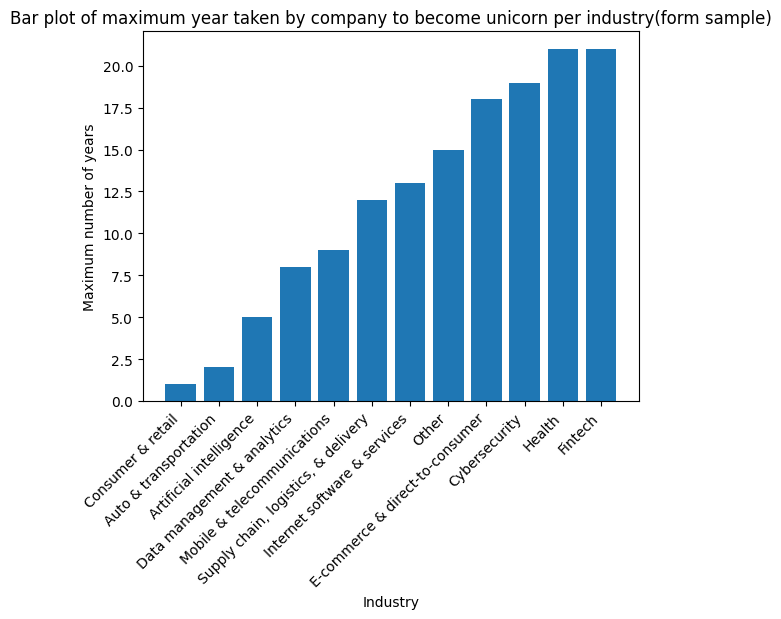

In [32]:
# create bar plot

plt.bar(grouped.index, grouped["years_till_unicorn"])

plt.title("Bar plot of maximum year taken by company to become unicorn per industry(form sample)")

plt.xlabel("Industry")
plt.ylabel("Maximum number of years")

# Rotate labels on the x-axis to avoid overlap in the postion of the text

plt.xticks(rotation=45, horizontalalignment = 'right')

plt.show()

### Visualize the maximum unicorn company valuation per industry

Visualize unicorn companies' maximum valuation for each industry represented in the sample. To create a bar plot to visualize this, use the `bar()` function from the `matplotlib.pyplot` module. Before plotting, create a new column that represents the companies' valuations as numbers (instead of strings, as they're currently represented). Then, use this new column to plot your data.

In [33]:
# Create a column representing company valuation as numeric data

# Create new column
companies_sample['valuation_billions'] = companies_sample['Valuation']
# Remove the '$' from each value
companies_sample['valuation_billions'] = companies_sample['valuation_billions'].str.replace('$', '')
# Remove the 'B' from each value
companies_sample['valuation_billions'] = companies_sample['valuation_billions'].str.replace('B', '')
# Convert column to type int
companies_sample['valuation_billions'] = companies_sample['valuation_billions'].astype('int')
companies_sample.head()

,Company,Valuation,Date Joined,Industry,City,Country/Region,Continent,Year Founded,Funding,Select Investors,Year Joined,years_till_unicorn,valuation_billions
542,Aiven,$2B,2021-10-18,Internet software & services,Helsinki,Finland,Europe,2016,$210M,"Institutional Venture Partners, Atomico, Early...",2021,5,2
370,Jusfoun Big Data,$2B,2018-07-09,Data management & analytics,Beijing,China,Asia,2010,$137M,"Boxin Capital, DT Capital Partners, IDG Capital",2018,8,2
307,Innovaccer,$3B,2021-02-19,Health,San Francisco,United States,North America,2014,$379M,"M12, WestBridge Capital, Lightspeed Venture Pa...",2021,7,3
493,Algolia,$2B,2021-07-28,Internet software & services,San Francisco,United States,North America,2012,$334M,"Accel, Alven Capital, Storm Ventures",2021,9,2
350,SouChe Holdings,$3B,2017-11-01,E-commerce & direct-to-consumer,Hangzhou,China,Asia,2012,$1B,"Morningside Ventures, Warburg Pincus, CreditEa...",2017,5,3


In [34]:
# Prepare data for modeling
grouped = (companies_sample[["Industry", "valuation_billions"]]
           .groupby("Industry")
           .max()
           .sort_values(by="valuation_billions")
          )
grouped

,valuation_billions
Industry,
Auto & transportation,1
Consumer & retail,1
Other,2
"Supply chain, logistics, & delivery",2
Cybersecurity,3
Health,3
E-commerce & direct-to-consumer,4
Data management & analytics,4
Internet software & services,5


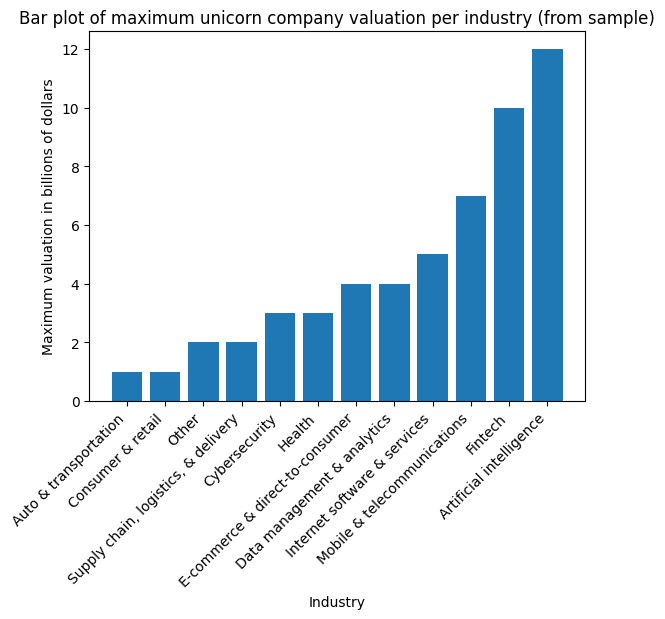

In [35]:
# Create bar plot
# with Industry column as the categories of the bars
# and new valuation column as the heights of the bars

### YOUR CODE HERE ###

plt.bar(grouped.index, grouped["valuation_billions"])

# Set title

### YOUR CODE HERE ###

plt.title("Bar plot of maximum unicorn company valuation per industry (from sample)")

# Set x-axis label

### YOUR CODE HERE ###

plt.xlabel("Industry")

# Set y-axis label

### YOUR CODE HERE ###

plt.ylabel("Maximum valuation in billions of dollars")

# Rotate labels on the x-axis as a way to avoid overlap in the positions of the text

### YOUR CODE HERE ###

plt.xticks(rotation=45, horizontalalignment='right')

# Display the plot

### YOUR CODE HERE ###

plt.show()

This bar plot shows that for this sample of unicorn companies, the highest maximum valuation occurred in the Artificial Intelligence industry, while the lowest maximum valuation occurred in the Auto & transportation, and Consumer & retail industries.